In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import seaborn as sns
import numpy as np
current_dir = os.getcwd()
project_root = os.path.dirname(current_dir)
if project_root not in sys.path:
    sys.path.append(project_root)

In [8]:
experiments = os.listdir("resultados_experimentos_mlp_logvar")
configs = os.listdir(os.path.join("resultados_experimentos_mlp_logvar", experiments[0]))
configs = filter(lambda x: ".yaml" in x, configs)
configs = list(configs)
configs = [config.replace(".yaml", "") for config in configs]
configs.sort()

# Config Base

In [14]:
exp_base = "hito3_32_compresion_mlp_original"
exp_summary = os.path.join("resultados_experimentos_mlp_logvar", exp_base,"summary_experiments.csv")
df_exp_base = pd.read_csv(exp_summary)    
df_exp_base.sort_values(by="experiment", inplace=True)    

## Acc Plot

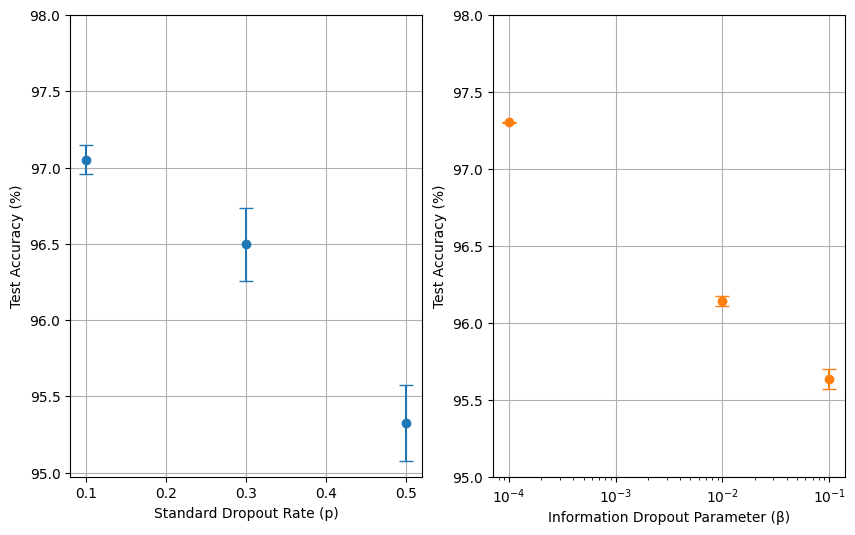

In [81]:
fig,axs = plt.subplots(1,2,figsize=(10, 6))

for k in range(len(df_exp_base)):
    experiment = df_exp_base.experiment[k]
    mean_acc = df_exp_base.mean_accuracy[k]
    std_acc = df_exp_base.std_accuracy[k]

    experiment_number = experiment.split("_")[-1].replace("0", "0.", 1)
    if experiment_number =="0.001":
        experiment_number = "0.0001"

    if "standard" in experiment:
        axs[0].errorbar(float(experiment_number), mean_acc, yerr=std_acc, fmt='o', capsize=5, color="tab:blue")
    else:
        axs[1].errorbar(float(experiment_number), mean_acc, yerr=std_acc, fmt='o', capsize=5, color="tab:orange")

axs[1].set_xscale('log')
axs[0].set_xlabel('Standard Dropout Rate (p)')
axs[0].set_ylabel('Test Accuracy (%)')
axs[1].set_xlabel('Information Dropout Parameter (β)')
axs[1].set_ylabel('Test Accuracy (%)')
axs[0].set_yticks([98,97.5,97,96.5,96,95.5,95])
axs[1].set_yticks([98,97.5,97,96.5,96,95.5,95])
axs[0].grid()
axs[1].grid()
plt.show()


## Losses Base

In [55]:
def cargar_experimento(folder, n_seeds=3, etiqueta="Info Dropout",beta=0):
    dfs = []
    for seed in range(n_seeds):
        filename = os.path.join(folder,f"losses_{seed}.csv")
        
        temp_df = pd.read_csv(filename)
        if etiqueta=="Info Dropout":
            temp_df["train_losses"] = temp_df["train_losses"]-beta*temp_df["train_kl_losses"]
            temp_df["val_losses"] = temp_df["val_losses"]-beta*temp_df["val_kl_losses"]
        temp_df['epoch'] = temp_df.index
        temp_df['seed'] = seed
        temp_df['model'] = etiqueta
        dfs.append(temp_df)
    
    return pd.concat(dfs, ignore_index=True)

c:\Users\sebas\anaconda3\envs\pytorchgpu\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\sebas\anaconda3\envs\pytorchgpu\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


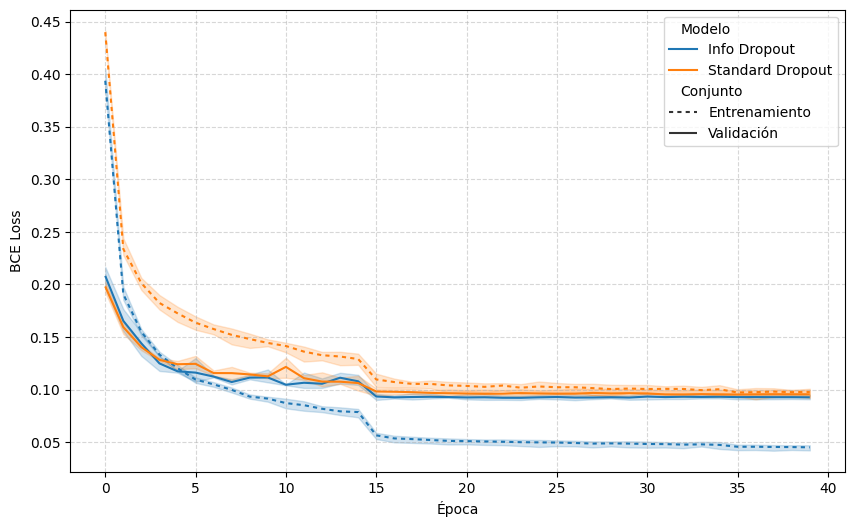

In [80]:
df_beta = cargar_experimento(folder = os.path.join("resultados_experimentos_mlp_logvar", exp_base,"results","info_beta_0001","losses"),n_seeds=3,etiqueta="Info Dropout",beta=0.0001)
df_p = cargar_experimento(folder = os.path.join("resultados_experimentos_mlp_logvar", exp_base,"results","standard_p_01","losses"),n_seeds=3,etiqueta="Standard Dropout")
df_total = pd.concat([df_beta, df_p])
df_plot = df_total.melt(
    id_vars=['epoch', 'seed', 'model'], 
    value_vars=['train_losses', 'val_losses'],
    var_name='phase', 
    value_name='loss'
)

# Renombrar para que se vea bonito en la leyenda
df_plot['Conjunto'] = df_plot['phase'].replace({
    'train_losses': 'Entrenamiento', 
    'val_losses': 'Validación'
})
df_plot["Modelo"] = df_plot["model"]
# 3. Graficar
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df_plot,
    x='epoch', 
    y='loss', 
    hue='Modelo',   #Color por set (Train/Val)
    style='Conjunto', #Línea (Sólida/Punteada)
    dashes={'Entrenamiento': (2, 2), 'Validación': (1, 0)},
    markers=False
)

plt.ylabel('BCE Loss')
plt.xlabel('Época')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Noisy Tests

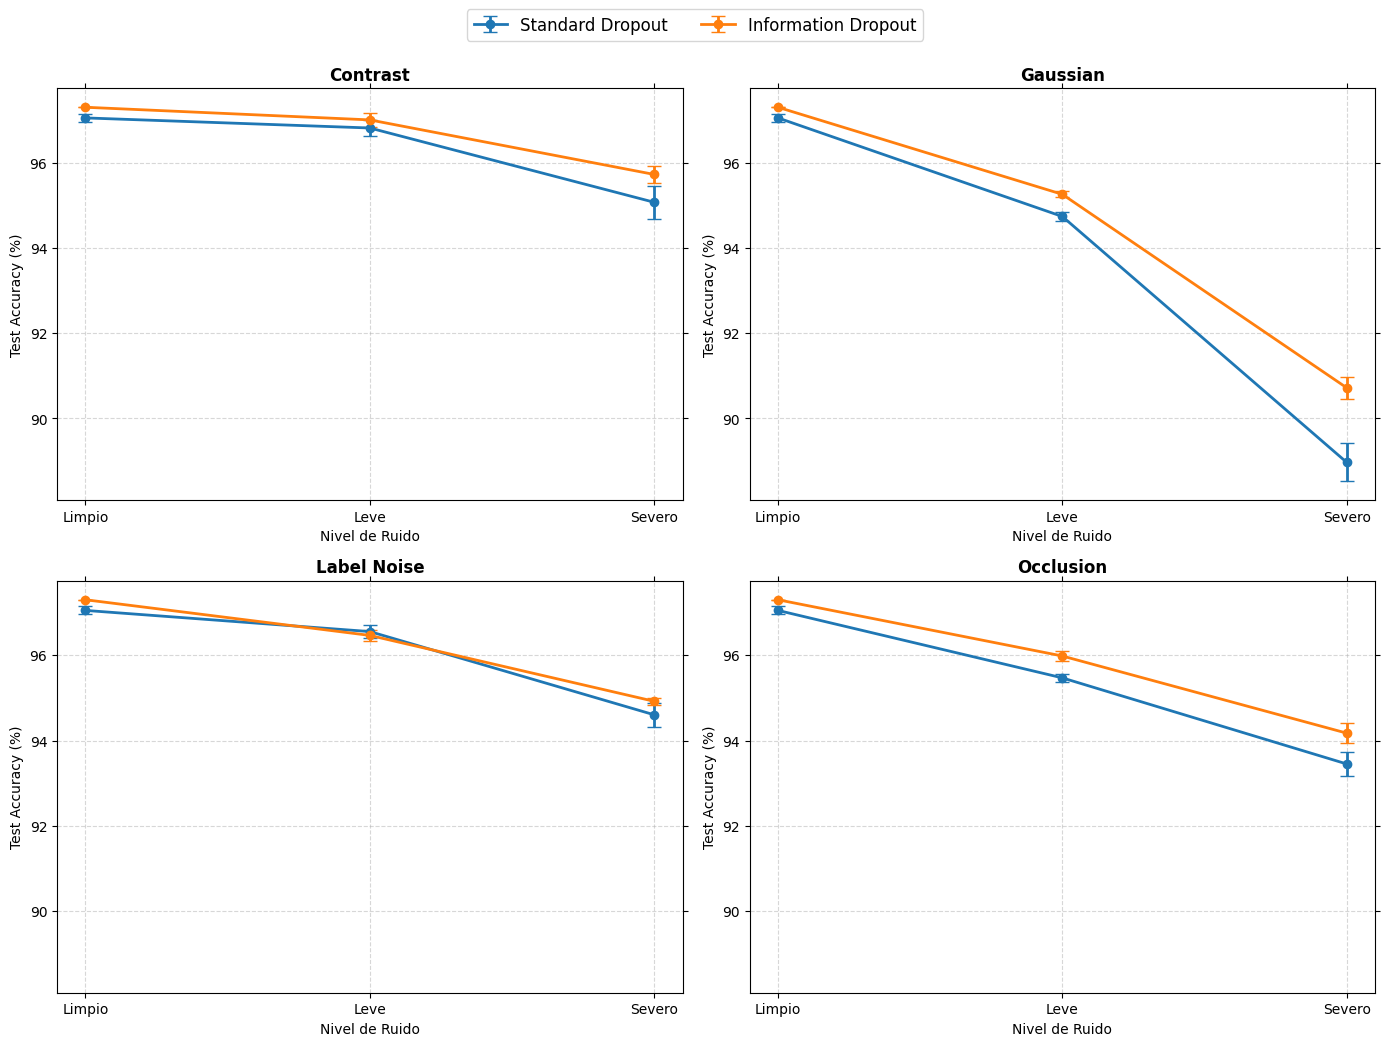

In [64]:
import pandas as pd
import matplotlib.pyplot as plt


fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True) 
axes = axes.flatten()

for i, noise_name in enumerate(noise_config.keys()):
    ax = axes[i]
    data_subset = df_plot[df_plot['Noise Type'] == noise_name].sort_values('Severity Order')
    
    # Standard Dropout
    std_data = data_subset[data_subset['Method'] == 'Standard Dropout']
    ax.errorbar(
        x=std_data['Severity Label'], y=std_data['Accuracy'], yerr=std_data['Std'],
        fmt='-o', color='tab:blue', linewidth=2, capsize=5, 
        label='Standard Dropout' if i == 0 else ""
    )
    
    # Information Dropout
    info_data = data_subset[data_subset['Method'] == 'Information Dropout']
    ax.errorbar(
        x=info_data['Severity Label'], y=info_data['Accuracy'], yerr=info_data['Std'],
        fmt='-o', color='tab:orange', linewidth=2, capsize=5, 
        label='Information Dropout' if i == 0 else ""
    )
    
    ax.set_title(noise_name, fontweight='bold', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # TICKS Y LABELS EN TODOS
    ax.set_xlabel("Nivel de Ruido", fontsize=10)
    ax.set_ylabel("Test Accuracy (%)", fontsize=10)
    
    ax.tick_params(
        axis='both',       # Aplicar a X e Y
        which='both',      # Mayor y menor
        bottom=True, top=True, left=True, right=True, # Marcas en los 4 lados
        labelbottom=True, labelleft=True              # Etiquetas visibles
    )

# Leyenda global
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2, fontsize=12)

plt.tight_layout()
plt.savefig('analisis_robustez.png', bbox_inches='tight', dpi=300)
plt.show()


# LogVar Tracking para Distintos Betas

c:\Users\sebas\anaconda3\envs\pytorchgpu\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\sebas\anaconda3\envs\pytorchgpu\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\sebas\anaconda3\envs\pytorchgpu\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\sebas\anaconda3\envs\pytorchgpu\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed

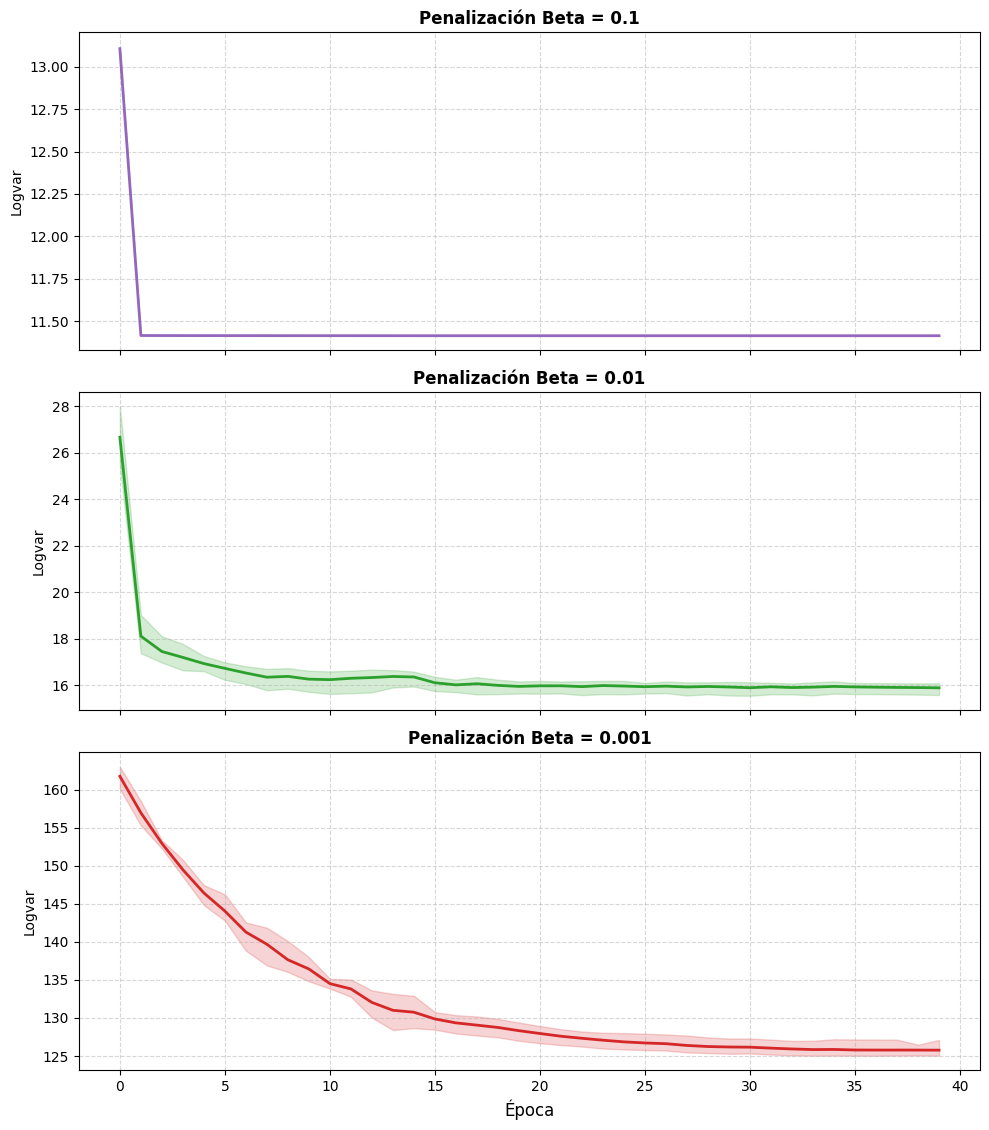

In [ ]:
path_01 = os.path.join("resultados_experimentos_mlp_logvar","hito3_32_compresion_mlp_original","results","info_beta_01","losses")
path_001 = os.path.join("resultados_experimentos_mlp_logvar","hito3_32_compresion_mlp_original","results","info_beta_001","losses")
path_0001 = os.path.join("resultados_experimentos_mlp_logvar","hito3_32_compresion_mlp_original","results","info_beta_0001","losses")

archivos_por_beta = {
    0.1:   [os.path.join(path_01,'losses_0.csv'), os.path.join(path_01,'losses_1.csv'), os.path.join(path_01,'losses_2.csv')],
    0.01:  [os.path.join(path_001,'losses_0.csv'), os.path.join(path_001,'losses_1.csv'), os.path.join(path_001,'losses_2.csv')],
    0.001: [os.path.join(path_0001,'losses_0.csv'), os.path.join(path_0001,'losses_1.csv'), os.path.join(path_0001,'losses_2.csv')]
}

#3 subplots verticales (uno encima del otro)
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True, sharey=False)

colores = {0.1: 'tab:purple', 0.01: 'tab:green', 0.001: 'tab:red'}

betas_ordenados = sorted(archivos_por_beta.keys(), reverse=True) # [0.1, 0.01, 0.001]

for i, beta in enumerate(betas_ordenados):
    ax = axes[i]
    rutas = archivos_por_beta[beta]
    dfs = []
    
    # Cargar las 3 semillas
    for seed, ruta in enumerate(rutas):
        if os.path.exists(ruta):
            df = pd.read_csv(ruta)
            df['epoch'] = df.index
            df['seed'] = seed
            dfs.append(df)
        else:
            print(f"Archivo no encontrado: {ruta}")
            
    if not dfs:
        continue
        
    df_beta = pd.concat(dfs, ignore_index=True)
    
    # val_kl_losses raw
    sns.lineplot(
        data=df_beta, 
        x='epoch', 
        y='train_kl_losses', 
        ax=ax, 
        color=colores.get(beta, 'black'),
        linewidth=2
    )
    
    ax.set_title(f'Penalización Beta = {beta}', fontweight='bold', fontsize=12)
    ax.set_ylabel('Logvar', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    

plt.xlabel('Época', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

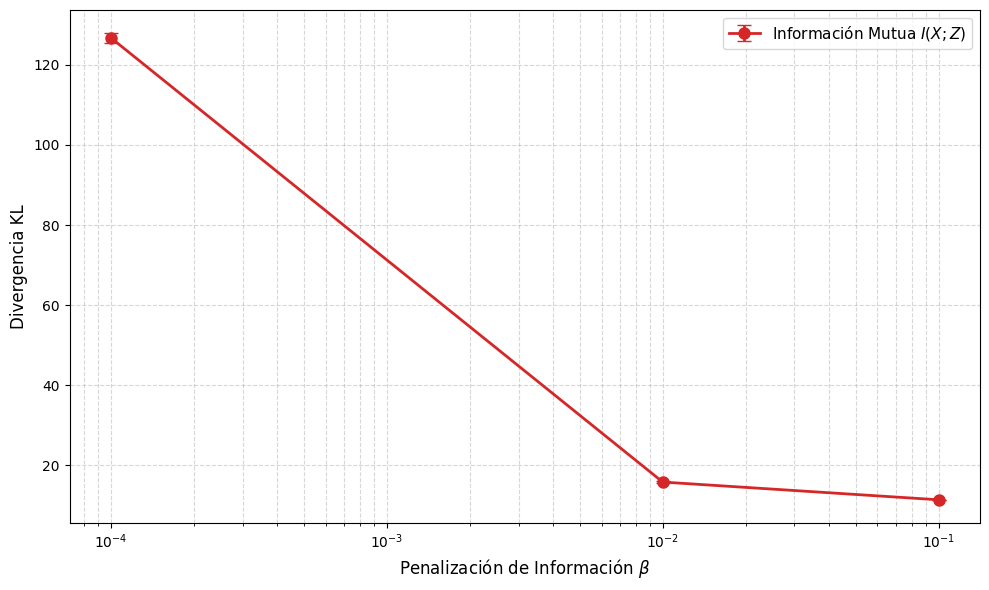

In [ ]:

df = pd.read_csv('summary_experiments_all.csv') 

FOLDER_BASE = 'hito3_32_compresion_mlp_original' 
if 'folder' in df.columns:
    df = df[df['folder'] == FOLDER_BASE]

#Filtrar filas que sean de Info Dropout
df_info = df[df['experiment'].str.contains('info_beta')].copy()

#Función para extraer el valor de Beta del nombre
def get_beta(exp_str):
    val_str = exp_str.split('_')[-1]
    
    if val_str.startswith('0') and '.' not in val_str:
        return float("0." + val_str[1:])
    
    return float(val_str)

df_info['beta'] = df_info['experiment'].apply(get_beta)
#Corrección necesaria
df_info['beta'] = df_info['beta'].replace(0.001, 0.0001)

#Se calcula KL cruda
df_info['raw_kl'] = df_info['mean_kl_loss'] / df_info['beta']
df_info['raw_kl_std'] = df_info['std_kl_loss'] / df_info['beta']

df_info = df_info.sort_values('beta')
#Grafico
plt.figure(figsize=(10, 6))

# Escala Log
plt.errorbar(
    x=df_info['beta'],
    y=df_info['raw_kl'],
    yerr=df_info['raw_kl_std'], # Barras de error (varianza entre semillas)
    fmt='-o',
    color='tab:red',
    linewidth=2,
    capsize=5,
    markersize=8,
    label=r'Información Mutua $I(X;Z)$'
)

# Estética
plt.xscale('log')

plt.xlabel(r'Penalización de Información $\beta$', fontsize=12)
plt.ylabel('Divergencia KL', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5, which='both')
plt.legend(fontsize=11)


plt.tight_layout()

plt.show()

# Histogramas Activación

c:\Users\sebas\anaconda3\envs\pytorchgpu\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\sebas\anaconda3\envs\pytorchgpu\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


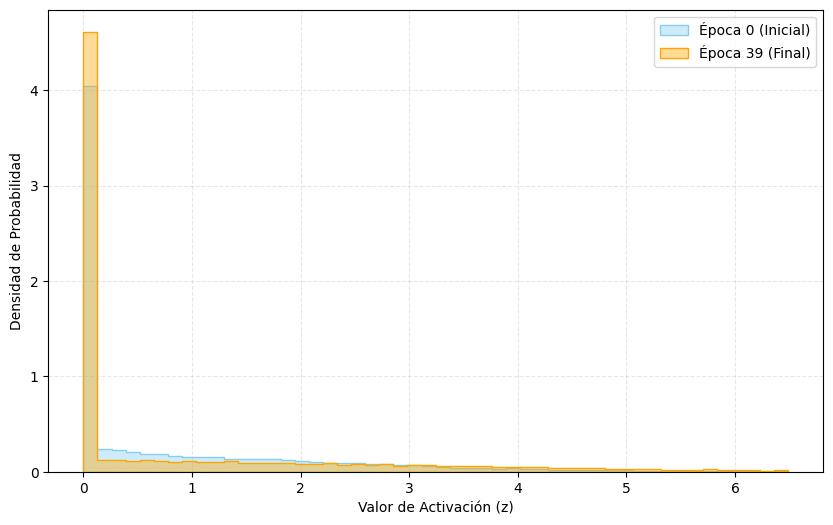

In [ ]:
epoch_0 = np.load(os.path.join('activation_hists','epoch_000.npy'))
epoch_39 = np.load(os.path.join('activation_hists','epoch_039.npy'))

plt.figure(figsize=(10, 6))

# Rango común
all_data = np.concatenate([epoch_0, epoch_39])
# Hasta percentil 99 para que los outliers no "aplasten" el gráfico
bin_range = (0, np.percentile(all_data, 99)) 

# Época 0
sns.histplot(epoch_0, bins=50, stat="density", 
             color="skyblue", label="Época 0 (Inicial)", 
             binrange=bin_range, alpha=0.4, element="step", fill=True)

# Época 39
sns.histplot(epoch_39, bins=50, stat="density", 
             color="orange", label="Época 39 (Final)", 
             binrange=bin_range, alpha=0.4, element="step", fill=True)

plt.xlabel("Valor de Activación (z)")
plt.ylabel("Densidad de Probabilidad")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()